# SPAD timing jitter for timestamp $g^{(2)}$

This notebook starts from the same thermal timestamp simulation as `01_timestamp_g2_basics.ipynb`, then applies SPAD timing jitter to see how detector timing resolution smears the measured bunching peak. The brightness control is the per-detector `average_count_rate`; the exposure is chosen from the number of accidental pairs per `g2` bin needed to reach a target detection significance after jitter broadening.

## Workflow

1. Build the same filtered thermal source model used in the basic timestamp notebook.
2. Estimate the jitter-smeared peak contrast and choose how many sigma above the Poisson noise the bunching detection should be.
3. Convert that target significance into required pairs per `g2` bin, exposure time, and number of simulated chunks.
4. Generate two timestamp streams from the fluctuating thermal intensity.
5. Apply Gaussian SPAD timing jitter to both timestamp streams.
6. Compare the Poisson-limited timestamp correlation with the jittered timestamp correlation.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from astropy import units as u
from astropy.constants import c

In [22]:
def sample_electric_field_from_psd(psd_shape, rng):
    """Draw a complex Gaussian thermal electric field from a normalized PSD."""
    
    n_samples = psd_shape.size
    gaussian_noise = (rng.normal(size=n_samples) + 1j * rng.normal(size=n_samples)) / np.sqrt(2)

    field_frequency = np.sqrt(psd_shape) * gaussian_noise
    field_time = np.fft.ifft(np.fft.ifftshift(field_frequency), norm="ortho")
    
    return field_time, field_frequency
    
def plot_photon_rate(ax, time_grid, count_rate, plot_window):

    if plot_window < 1 * u.ns: time_unit = u.ps
    elif plot_window < 1 * u.us: time_unit = u.ns
    else: time_unit = u.us

    plot_n = int((plot_window / dt).decompose().value)
    ax.plot(time_grid[:plot_n].to_value(time_unit), count_rate[:plot_n].to_value(1 / u.s))
    ax.set_xlabel(f"Time [{time_unit}]")
    ax.set_ylabel("Photon rate [counts/s]")
    ax.set_title(f"{plot_window:g} time window")
    ax.grid(alpha=0.25)

def sample_electric_field_from_psd(psd_shape, rng):
    """Draw a complex Gaussian thermal electric field from a normalized PSD."""
    
    n_samples = psd_shape.size
    gaussian_noise = (rng.normal(size=n_samples) + 1j * rng.normal(size=n_samples)) / np.sqrt(2)

    field_frequency = np.sqrt(psd_shape) * gaussian_noise
    field_time = np.fft.ifft(np.fft.ifftshift(field_frequency), norm="ortho")
    
    return field_time, field_frequency
    
def estimate_g2_detection(target_sigma, jitter_fwhm, tau_c, g2_bin_width, average_count_rate):
    
    # For a unit amplitude Gaussian: g2(tau) - 1 = exp(-tau^2 / (2 sigma^2))
    # tau_c = integral(g2 - 1) dtau = sigma sqrt(2 pi)
    sigma_intrinsic = tau_c / np.sqrt(2 * np.pi)

    # Pair jitter broadening from two independent detectors
    jitter_sigma = jitter_fwhm / 2.355
    sigma_pair_jitter = np.sqrt(2) * jitter_sigma

    # Histogram bin broadening from a uniform bin of width Delta tau
    sigma_bin = g2_bin_width / np.sqrt(12)
    sigma_eff = np.sqrt(sigma_intrinsic**2 + sigma_pair_jitter**2 + sigma_bin**2)

    peak_contrast = sigma_intrinsic / sigma_eff
    pairs_per_bin_needed = (target_sigma / peak_contrast)**2
    exposure_needed = (pairs_per_bin_needed /(average_count_rate**2 * g2_bin_width)).to(u.ns)

    return {
        "sigma_intrinsic": sigma_intrinsic,
        "sigma_pair_jitter": sigma_pair_jitter,
        "sigma_bin": sigma_bin,
        "sigma_eff": sigma_eff,
        "peak_contrast": peak_contrast,
        "expected_peak": 1 + peak_contrast,
        "pairs_per_bin_needed": pairs_per_bin_needed,
        "exposure_needed": exposure_needed,
    }

def sample_timestamps_from_rate(rate, dt, rng):
    """
    Sample timestamps from a binned inhomogeneous Poisson process.
    Assumes rate has units of 1/time and dt has the corresponding time
    units, so that rate * dt is the expected count per bin.
    """
    counts = rng.poisson(rate * dt)

    nonzero_bins = np.flatnonzero(counts)
    repeated_bins = np.repeat(nonzero_bins, counts[nonzero_bins])
    sub_bin_offsets = rng.uniform(0.0, dt, size=repeated_bins.size)
    
    return np.sort(repeated_bins * dt + sub_bin_offsets)

def g2_from_timestamps(timestamps1, timestamps2, exposure_time, bin_width, max_lag):
    """Estimate g² from continuous timestamp pairs using a delay histogram."""

    t1 = timestamps1.to_value(bin_width.unit)
    t2 = timestamps2.to_value(bin_width.unit)

    exposure = exposure_time.to_value(bin_width.unit)
    bin_width_value = bin_width.to_value(bin_width.unit)
    max_lag_value = max_lag.to_value(bin_width.unit)

    edges = np.arange(-max_lag_value, max_lag_value + bin_width_value, bin_width_value)
    bin_centers = edges[:-1] + bin_width_value / 2.0
    counts = np.zeros(edges.size - 1)

    for t in tqdm(t1):
        left = np.searchsorted(t2, t - max_lag_value)
        right = np.searchsorted(t2, t + max_lag_value)
        delays = t2[left:right] - t
        counts += np.histogram(delays, bins=edges)[0]

    tau = 0.5 * (edges[:-1] + edges[1:]) * bin_width.unit

    rate1 = len(t1) / exposure
    rate2 = len(t2) / exposure

    # There is a triangular overlap function that becomes important at short exposure time 
    # Short compared the maximum lag.
    overlap = exposure - np.abs(tau.to_value(bin_width.unit))
    expected_accidentals = rate1 * rate2 * overlap * bin_width_value
    g2 = counts / expected_accidentals
    
    return tau, g2
    
def coherence_time_from_g2_area(tau, g2, peak_window, baseline_window):
    """Estimate coherence time from the area of the g² peak above the measured baseline.
    For idealized g² the baseline is exactly 1, but measured timestamp correlations
    can have a small baseline offset due to finite counting statistics.
    """
    baseline_mask = (
        (np.abs(tau) >= baseline_window[0])
        & (np.abs(tau) <= baseline_window[1])
    )
    baseline = np.mean(g2[baseline_mask])

    peak_mask = np.abs(tau) <= peak_window
    tau_c = np.trapezoid(g2[peak_mask] - baseline, tau[peak_mask])

    return tau_c.to(u.ps), baseline

In [23]:
# Compute g2 with SPAD jitter 
# Photon statistics controls.
# average_count_rate is the per-detector mean count rate.
# target_pairs_per_bin is the desired accidental pair count in one g2 histogram bin.
jitter_fwhm = 50 * u.ps
target_sigma = 5
average_count_rate = 1e11 / u.s
g2_bin_width = 0.1 * u.ps
average_count_rate = 10 / u.ps

# Duration of one FFT realization. Total integration time is built by
# accumulating many independent realizations, not by increasing n_time.
n_time = 2**14
dt = 0.1 * u.ps
total_time = (n_time * dt).to(u.ns)
chunk_time = n_time * dt
time_unit = u.ps

# Central wavelength and filter width
lambda_center = 500.0 * u.nm
fwhm_lambda = 1 * u.nm
sigma_lambda = fwhm_lambda / 2.355
fwhm_nu = (c * fwhm_lambda / lambda_center**2).to(u.THz)

# Convert wavelength to frequency grid for FFT and corresponding wavelength grid
nu_center = (c / lambda_center).to('THz')
nu_offset = np.fft.fftshift(np.fft.fftfreq(n_time, d=dt))
nu_grid = nu_center + nu_offset
lambda_grid = (c / nu_grid).to('nm')

# Filter transmission function in wavelengths
filter_transmission = np.exp(-0.5 * ((lambda_grid - lambda_center) / sigma_lambda)**2)
filter_transmission /= np.max(filter_transmission)

# Flat star-psd could later be upgraded
# Detector PSD is a normalized coherence shape, defined here in wavelength space.
psd_star = np.ones(lambda_grid.shape)
psd_detector = psd_star * filter_transmission

# Coherence time implied by the detector PSD:
# tau_c = ∫S(ν)^2 dν / (∫S(ν)dν)^2
delta_nu = np.abs(np.mean(np.diff(nu_grid)))
tau_c_truth = (
    np.sum(psd_detector**2) * delta_nu
    / (np.sum(psd_detector) * delta_nu)**2
).to(u.ps)


# Thermal electric field realization
rng = np.random.default_rng(7)
time_grid = np.arange(n_time) * dt
field_t, field_freq = sample_electric_field_from_psd(psd_detector, rng)

# Instantaneous optical intensity
intensity = np.abs(field_t) ** 2

# Convert normalized intensity fluctuations into a physical photon rate
count_rate = average_count_rate * intensity / intensity.mean()

# Thermal electric field realization
rng = np.random.default_rng(7)
time_grid = np.arange(n_time) * dt
field_t, field_freq = sample_electric_field_from_psd(psd_detector, rng)

# Instantaneous optical intensity
intensity = np.abs(field_t) ** 2

# Convert normalized intensity fluctuations into a physical photon rate
count_rate = average_count_rate * intensity / intensity.mean()

g2_estimates = estimate_g2_detection(
    target_sigma=target_sigma,
    jitter_fwhm=jitter_fwhm,
    tau_c=tau_c_truth,
    g2_bin_width=g2_bin_width,
    average_count_rate=average_count_rate,
)
exposure_time = g2_estimates['exposure_needed']
n_chunks = int(np.ceil((exposure_time / chunk_time).decompose().value))

print(f"Peak contrast             : {g2_estimates['peak_contrast']:.3e}")
print(f"Jitter expected peak      : {g2_estimates['expected_peak']:.6f}")
print(f"Pairs/bin for 5 sigma     : {g2_estimates['pairs_per_bin_needed']:.3e}")
print(f"Exposure needed           : {g2_estimates['exposure_needed']:.3e}")
print(f"Chunks needed             : {n_chunks:,}")

Peak contrast             : 7.361e-03
Jitter expected peak      : 1.007361
Pairs/bin for 5 sigma     : 4.614e+05
Exposure needed           : 4.614e+01 ns
Chunks needed             : 29


In [24]:
def apply_jitter(timestamps, jitter_sigma, rng):
    """Apply Gaussian timing jitter to timestamps."""
    return np.sort(timestamps + rng.normal(loc=0.0, scale=jitter_sigma, size=timestamps.size))

dt_num = dt.to_value(time_unit)
chunk_time_num = chunk_time.to_value(time_unit)

timestamps = {"spad1": [], "spad2": []}
timestamps_jitter = {"spad1": [], "spad2": []}

for chunk_id in tqdm(range(n_chunks)):
    chunk_start = chunk_id * chunk_time_num

    field_t, _ = sample_electric_field_from_psd(psd_detector, rng)
    intensity = np.abs(field_t) ** 2

    count_rate = average_count_rate * intensity / intensity.mean()
    rate_num = count_rate.to_value(1 / time_unit)

    timestamps['spad1'].extend(
        sample_timestamps_from_rate(rate_num, dt_num, rng) + chunk_start
    )
    timestamps['spad2'].extend(
        sample_timestamps_from_rate(rate_num, dt_num, rng) + chunk_start
    )
    
timestamps["spad1"] = np.array(timestamps["spad1"]) * time_unit
timestamps["spad2"] = np.array(timestamps["spad2"]) * time_unit

jitter_sigma_num = jitter_fwhm.to_value(time_unit) / 2.355
timestamps_jitter["spad1"] = apply_jitter(timestamps["spad1"].to_value(time_unit), jitter_sigma_num, rng) * time_unit
timestamps_jitter["spad2"] = apply_jitter(timestamps["spad2"].to_value(time_unit), jitter_sigma_num, rng) * time_unit

# Clip times outside of [0, exposure]
for spad in timestamps_jitter.keys(): 
    valid_indices = (timestamps_jitter[spad] >= 0) & (timestamps_jitter[spad] <= exposure_time)
    timestamps_jitter[spad] = timestamps_jitter[spad][valid_indices]

  0%|          | 0/29 [00:00<?, ?it/s]

In [25]:
# Define paraemeters for integration
max_lag = 5 * u.ps
peak_window = 1 * u.ps
baseline_window = (2 * u.ps, 4 * u.ps)

# compute g2 from SPAD1 and SPAD2 arrivals (timestamp data)
tau_poisson, g2_poisson = g2_from_timestamps(
    timestamps["spad1"],
    timestamps["spad2"],
    exposure_time=exposure_time,
    bin_width=g2_bin_width,
    max_lag=max_lag,
)
tau_c_poisson, baseline_poisson = coherence_time_from_g2_area(tau_poisson, g2_poisson, peak_window, baseline_window)


# Define paraemeters for integration
sigma_eff = g2_estimates['sigma_eff']
max_lag = 5 * sigma_eff
peak_window = 3 * sigma_eff
baseline_window = (4 * sigma_eff, 5 * sigma_eff)
bin_width = sigma_eff / 5.0

tau_jitter, g2_jitter = g2_from_timestamps(
    timestamps_jitter["spad1"],
    timestamps_jitter["spad2"],
    exposure_time=exposure_time,
    bin_width=bin_width,
    max_lag=max_lag,
)
tau_c_jitter, baseline_jitter = coherence_time_from_g2_area(tau_jitter, g2_jitter, peak_window, baseline_window)

  0%|          | 0/474439 [00:00<?, ?it/s]

  0%|          | 0/460714 [00:00<?, ?it/s]

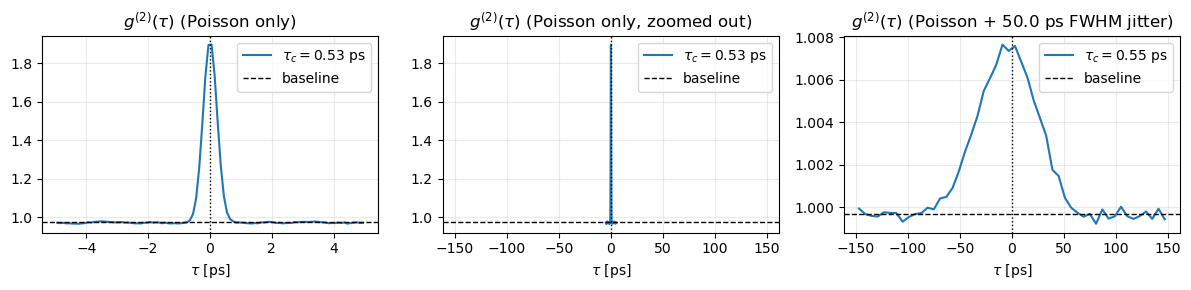

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=False)
axes[2].sharex(axes[1])

# g2 without jitter 
axes[0].plot(tau_poisson.to_value(u.ps), g2_poisson, label=rf"$\tau_c={tau_c_poisson.to_value(u.ps):.2f}$ ps")
axes[0].axhline(baseline_poisson, color="k", ls="--", lw=1, label="baseline")
axes[0].axvline(0.0, color="k", ls=":", lw=1)
axes[0].set_xlabel(r"$\tau$ [ps]")
axes[0].set_title(r"$g^{(2)}(\tau)$ (Poisson only)")
axes[0].grid(alpha=0.25)
axes[0].legend()


# g2 without jitter zoomed out 
axes[1].plot(tau_poisson.to_value(u.ps), g2_poisson, label=rf"$\tau_c={tau_c_poisson.to_value(u.ps):.2f}$ ps")
axes[1].axhline(baseline_poisson, color="k", ls="--", lw=1, label="baseline")
axes[1].axvline(0.0, color="k", ls=":", lw=1)
axes[1].set_xlabel(r"$\tau$ [ps]")
axes[1].set_title(r"$g^{(2)}(\tau)$ (Poisson only, zoomed out)")
axes[1].grid(alpha=0.25)
axes[1].legend()

# g2 with jitter
axes[2].plot(tau_jitter.to_value(u.ps), g2_jitter, label=rf"$\tau_c={tau_c_jitter.to_value(u.ps):.2f}$ ps")
axes[2].axhline(baseline_jitter, color="k", ls="--", lw=1, label="baseline")
axes[2].axvline(0.0, color="k", ls=":", lw=1)
axes[2].set_xlabel(r"$\tau$ [ps]")
axes[2].set_title(
    rf"$g^{{(2)}}(\tau)$ (Poisson + {jitter_fwhm.to_value(u.ps):.1f} ps FWHM jitter)"
)
axes[2].grid(alpha=0.25)
axes[2].legend()

fig.tight_layout()
plt.show()